## Бонусное ДЗ №4 Нейросетевое моделирование следующей корзины

#### В этой домашке вам предстоит реализовать нейросеть, которая моделирует паттерны повторных покупок людей

#### Дата выдачи: 11.06.25

#### Жесткий дедлайн: 18.06.25 23:59 MSK

## Описание задания

В этом задании вам предстоит реализовать нейронную сеть для моделирования поведения пользователей в доменах с высокой частотой повторяющихся взаимодействий между пользователями и товарами (айтемами).

### Структура задания

Задание состоит из трёх основных блоков:

1. **Подготовка данных и базовый подход (макс 3 балла)**
   - Подготовка датасета для экспериментов
   - Реализация простого базового решения (TopPersonal) для последующего сравнения

2. **Реализация нейронной сети BasketHSERec (макс 4 балла)**
   - Реализация архитектуры, моделирующей динамику взаимодействий пользователя с каждым конкретным товаром
   - Учёт временных закономерностей в истории покупок

3. **Эксперименты и анализ (макс 3 балла)**
   - Проведение сравнительных экспериментов между предложенной моделью и базовым подходом
   - Анализ результатов и формулирование выводов

### Особенности задачи

Задание фокусируется на сценариях с:
- Высокой повторяемостью покупок (например, продукты питания, бытовая химия)
- Важностью временных паттернов в поведении пользователей
- Необходимостью персонализированных рекомендаций на основе истории взаимодействий

# Описание модели BasketHSERec


Авторам задания не известна научная статья, в которой бы точно описывалась предлагаемая архитектура, однако она частично вдохновлена упрощёнными идеями из следующих работ:
1. [ReCaNet](https://irlab.science.uva.nl/wp-content/papercite-data/pdf/ariannezhad-2022-recanet.pdf)
2. Недавняя статья [SAFeRec](https://arxiv.org/pdf/2412.14302) от авторов курса. На самом деле, BasketHSERec - это SAFeRec, но без трансформерной части, чтобы не усложнять реализацию

## Постановка задачи

Пусть имеется:
- Множество пользователей $u \in U$
- Множество товаров (айтемов) $i \in I$

Для каждого пользователя составим матрицу $W^u \in \mathbb{R}^{T \times |I|}$, где $w_t^u$ - multihot-вектор корзины покупок в момент времени $t$. 

Здесь:
- $t$ представляет дискретные периоды времени от 1 до $T$ (например, дни)
- $w_{t,i}^u = 1$, если пользователь купил товар $i$ в момент $t$, и $0$ в противном случае

**Важно**: матрица будет очень разреженной, поэтому необходимо использовать структуры данных для работы с разреженными матрицами. Но, можно попробовать и на full-connected слоях

Задача: предсказать следующую корзину покупок пользователя в момент времени $T+1$ (например, на следующий день). 

**Примечание**: при валидации на разных временных отрезках значение $T$ будет разным для разных пользователей.


## Базовый подход (TopPersonal)


Для пользователя $u$ с историей покупок  $W^u \in \mathbb{R}^{T \times |I|}$:

1. **Суммарный вектор покупок**:
   $$
   s^u = \sum_{t=1}^T w_t^u \quad \in \mathbb{R}^{|I|}
   $$
   где $s_i^u$ — сколько раз пользователь $u$ покупал товар $i$.

2. **Добавление популярности товаров**:
   $$
   p_u^{\text{TopPersonal}} = s^u + pop_{i} \quad \in \mathbb{R}^{|I|}
   $$
   Здесь $\text{pop}_i$ - нормированная популярность товара

3. **Рекомендация**:
   - Сортируем товары по убыванию $ p_u^{\text{TopPersonal}} $
   - Топ-$k$ товаров — предсказанная корзина на $T+1$

## Мотивация для BasketHSERec

Рассмотрим вектор $h_u^i \in \mathbb{R}^T$ - строку в матрице $W^u$, соответствующую товару $i$. Если просто просуммировать его элементы, мы получим общее количество покупок товара, но не учтём временные закономерности.

**Пример**: Допустим, мы наблюдаем 10 дней, и пользователь купил кефир в 1-й, 3-й и 7-й дни. Тогда:

$$h_u^i = [1, 0, 1, 0, 0, 0, 1, 0, 0, 0]$$

Простое суммирование частот не учитывает периодичность покупок. Рассмотрим два случая:
1. $[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]$
2. $[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]$

В первом случае товар был куплен 10 дней назад, во втором - "вчера". Вероятность повторной покупки во втором случае выше, хотя это также зависит от паттернов покупок товара.

## Архитектура BasketHSERec

Определим модель как:

$$y_u^i = \text{BasketHSERec}(h_u^i) = f(h_u^i, i) \in \mathbb{R}$$

где $y_u^i$ предсказывает вероятность покупки товара $i$ пользователем $u$ в момент времени $T+1$.

### Реализация:
1. Функция $f(h_u^i, i)$:
   - Конкатенируем вектор $h_u^i$ и эмбеддинг товара $i$
   - Пропускаем через несколько полносвязных (FC) слоёв с нелинейной активацией
   - На выходе получаем одно число (вероятность покупки)

2. Функция потерь:
   - Используем бинарную кросс-энтропию для классификации (покупка/нет покупки)
   - **Важно**: рассматриваем только товары, которые пользователь уже покупал ранее


## Описание данных

Для выполнения задания используется датасет **Dunnhumby - The Complete Journey**, содержащий историю покупок пользователей. 

**Исходные данные**:  
[Официальная версия на Kaggle](https://www.kaggle.com/datasets/frtgnn/dunnhumby-the-complete-journey)  

**Подготовленная версия**:  
[Яндекс.Диск](https://disk.yandex.ru/d/PPpfc9a4I9Y38w) (удалены лишние колонки для удобства работы)

## Система оценивания

### 1. Подготовка данных (1 балл)
- [ ] Подготовлены обучающий и тестовый датасеты
- [ ] Использована схема разбиения:
  - Leave-one-basket (последняя корзина как тест) **или**
  - Time-based split (последний день как тест)
- [ ] *(Опционально)* Реализована валидационная выборка и перебор параметров

### 2. Реализация TopPersonal (2 балла)
- [ ] Корректно реализован алгоритм TopPersonal
- [ ] Рассчитаны метрики качества:
  - NDCG@3 и Recall@3
  - NDCG@10 и Recall@10
- [ ] Результаты представлены в понятном формате

### 3. Обучение BasketHSERec (2 балла)
- [ ] Реализован код обучения модели
- [ ] Продемонстрирован процесс обучения:
  - Графики обучения/потерь
  - Логи процесса (например, через tqdm)
- [ ] Сохранены веса обученной модели

### 4. Сравнение с TopPersonal (3 балла)
- [ ] Проведено сравнение BasketHSERec и TopPersonal
- [ ] Показано преимущество BasketHSERec по метрикам:
  - NDCG@3/10
  - Recall@3/10
- [ ] Результаты представлены в табличном виде с четкими выводами

### 5. Анализ архитектурных решений (2 балла)
- [ ] Проведено сравнение вариантов BasketHSERec:
  
  | Вариант               | NDCG@3 | Recall@3 | NDCG@10 | Recall@10 |
  |-----------------------|--------|----------|---------|-----------|
  | a) History + Embeddings |        |          |         |           |
  | b) Только Embeddings    |        |          |         |           |
  | c) Только History       |        |          |         |           |
  | TopPersonal (baseline)  |        |          |         |           |

- [ ] Сделаны содержательные выводы о влиянии компонентов модели

In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_parquet('dunnhumby_norm.pq')
df.head()

,user_id,day,item_id
0,2375,1,1004906
1,2375,1,1033142
2,2375,1,1036325
3,2375,1,1082185
4,2375,1,8160430


In [55]:
def ndcg_metric(gt_items, predicted):
    
    at = len(predicted)
    relevance = np.array([1 if x in predicted else 0 for x in gt_items])
    rank_dcg = dcg(relevance)

    if rank_dcg == 0.0:
        return 0.0

    ideal_dcg = dcg(np.sort(relevance)[::-1][:at])

    if ideal_dcg == 0.0:
        return 0.0

    ndcg_ = rank_dcg / ideal_dcg

    return ndcg_


def dcg(scores):
    return np.sum(np.divide(np.power(2, scores) - 1, np.log2(np.arange(scores.shape[0], dtype=np.float64) + 2)),
                  dtype=np.float64)


def recall_metric(gt_items, predicted):
    
    n_gt = len(gt_items)
    intersection = len(set(gt_items).intersection(set(predicted)))
    return intersection / n_gt

def evaluate_recommender(df, model_preds, gt_col='test_interactions', topn=10):
    
    metric_values = []
    
    for idx, row in df.iterrows():
        gt_items = [x[1] for x in row[gt_col]]
        metric_values.append((ndcg_metric(gt_items, row[model_preds][:topn]),
                              recall_metric(gt_items, row[model_preds][:topn])))
        
    return {'ndcg':np.mean([x[0] for x in metric_values]),
            'recall':np.mean([x[1] for x in metric_values])}



### 1. Подготовка данных (1 балл)


In [4]:
print(f'В датасете {df["user_id"].nunique()} юзеров')
print(f'В датасете {df["item_id"].nunique()} айтемов')
print(f'Датасет собран за {df["day"].nunique()} дней')

В датасете 2500 юзеров
В датасете 92339 айтемов
Датасет собран за 711 дней


In [5]:
# создадим идентификатор корзины, где "1" = последняя купленная корзина
df['basket_id'] = df.groupby('user_id')['day'].rank(method='dense', ascending=False).astype(int)

In [6]:
# закодируем юзеров и айтемы, чтобы они принимали значение от 0 до N
user2id = {x: idx for idx, x in enumerate(df.user_id.unique())}
item2id = {x: idx for idx, x in enumerate(df.item_id.unique())}

df['user_id_decoded'] = df['user_id'].apply(lambda x: user2id[x])
df['item_id_decoded'] = df['item_id'].apply(lambda x: item2id[x])

In [7]:
# разобъем данные на трейн, валидацию и тест по схеме Leave-one-basket (последня корзина - тест, предпоследняя - валидация)
train_baskets = df.loc[df['basket_id'] > 2].copy()
valid_baskets = df.loc[df['basket_id'] == 2].copy()
test_baskets = df.loc[df['basket_id'] == 1].copy()

In [ ]:
train_baskets.to_csv('train_baskets.csv', index=False)
valid_baskets.to_csv('valid_baskets.csv', index=False)
test_baskets.to_csv('test_baskets.csv', index=False)

In [8]:
assert df.shape[0] == train_baskets.shape[0] + valid_baskets.shape[0] + test_baskets.shape[0]

In [9]:
train_grouped = train_baskets.groupby('user_id_decoded').apply(lambda x: list(zip(x.basket_id, x.item_id_decoded))).reset_index()
train_grouped.rename({0: 'train_baskets'}, axis=1, inplace=True)

valid_grouped = valid_baskets.groupby('user_id_decoded').apply(lambda x: list(zip(x.basket_id, x.item_id_decoded))).reset_index()
valid_grouped.rename({0: 'valid_baskets'}, axis=1, inplace=True)

test_grouped = test_baskets.groupby('user_id_decoded').apply(lambda x: list(zip(x.basket_id, x.item_id_decoded))).reset_index()
test_grouped.rename({0: 'test_baskets'}, axis=1, inplace=True)

grouped = train_grouped.merge(valid_grouped).merge(test_grouped)
grouped.head()

,user_id_decoded,train_baskets,valid_baskets,test_baskets
0,0,"[(95, 0), (95, 1), (95, 2), (95, 3), (95, 4), ...","[(2, 18530), (2, 5254)]","[(1, 1662)]"
1,1,"[(138, 11), (138, 12), (138, 13), (138, 14), (...","[(2, 907), (2, 5631), (2, 75072)]","[(1, 14), (1, 1736), (1, 14089), (1, 66660), (..."
2,2,"[(249, 16), (249, 17), (249, 18), (249, 19), (...","[(2, 3807), (2, 1774), (2, 5348), (2, 5504), (...","[(1, 5189)]"
3,3,"[(32, 21), (32, 22), (32, 23), (31, 444), (31,...","[(2, 6331), (2, 17017), (2, 22879), (2, 34264)...","[(1, 53544), (1, 38223), (1, 5210), (1, 23435)..."
4,4,"[(157, 24), (157, 25), (157, 26), (157, 3), (1...","[(2, 15426), (2, 8739), (2, 6444), (2, 3399), ...","[(1, 4150), (1, 1335), (1, 29323), (1, 731)]"


### 2. Реализация TopPersonal (2 балла)


In [57]:
popularity = train_baskets.drop_duplicates(subset=['user_id_decoded','item_id_decoded']).item_id_decoded.value_counts().reset_index()
popularity['count'] /= popularity['count'].max()
populartiy = {k: v for k, v in zip(popularity.item_id_decoded, popularity['count'])}

top_popular = train_baskets.drop_duplicates(subset=['user_id_decoded','item_id_decoded']).item_id_decoded.value_counts().index.tolist()[:10]

def topPersonalRecs(row, k=10):
    counts = {}
    for l in row.train_baskets:
        item = l[1]
        if item in counts:
            counts[item] += 1
        else:
            counts[item] = 1
    for t in counts:
        counts[t] += popularity.get(t, 0)
    counts = list(sorted(counts.items(), key=lambda x: -x[1]))
    
    items = [x[0] for x in counts][:k] 
    items = items + [x for x in top_popular if x not in items]
    
    return items[:k]


grouped['toppersonal_recs'] = grouped.apply(lambda x: topPersonalRecs(x), axis=1)
grouped.head()

,user_id_decoded,train_baskets,valid_baskets,test_baskets,top_personal_recs,toppersonal_recs
0,0,"[(95.0, 0), (95.0, 1), (95.0, 2), (95.0, 3), (...","[(2.0, 18530), (2.0, 5254)]","[(1.0, 1662)]","[3415, 1201, 358, 362, 1824, 3419, 58, 2787, 1...","[3415, 1201, 358, 362, 1824, 3419, 58, 2787, 1..."
1,1,"[(138.0, 11), (138.0, 12), (138.0, 13), (138.0...","[(2.0, 907), (2.0, 5631), (2.0, 75072)]","[(1.0, 14), (1.0, 1736), (1.0, 14089), (1.0, 6...","[1736, 3, 219, 2212, 3722, 17454, 28061, 50, 7...","[1736, 3, 219, 2212, 3722, 17454, 28061, 50, 7..."
2,2,"[(249.0, 16), (249.0, 17), (249.0, 18), (249.0...","[(2.0, 3807), (2.0, 1774), (2.0, 5348), (2.0, ...","[(1.0, 5189)]","[3, 3455, 1824, 159, 362, 5202, 6759, 235, 392...","[3, 3455, 1824, 159, 362, 5202, 6759, 235, 392..."
3,3,"[(32.0, 21), (32.0, 22), (32.0, 23), (31.0, 44...","[(2.0, 6331), (2.0, 17017), (2.0, 22879), (2.0...","[(1.0, 53544), (1.0, 38223), (1.0, 5210), (1.0...","[3756, 159, 758, 4213, 3, 5292, 219, 3755, 163...","[3756, 159, 758, 4213, 3, 5292, 219, 3755, 163..."
4,4,"[(157.0, 24), (157.0, 25), (157.0, 26), (157.0...","[(2.0, 15426), (2.0, 8739), (2.0, 6444), (2.0,...","[(1.0, 4150), (1.0, 1335), (1.0, 29323), (1.0,...","[5881, 4417, 24, 2212, 10172, 19003, 2276, 681...","[5881, 4417, 24, 2212, 10172, 19003, 2276, 681..."


In [83]:
metrics_at_3 = evaluate_recommender(grouped, gt_col='test_baskets',model_preds='toppersonal_recs', topn=3)
metrics_at_10 = evaluate_recommender(grouped, gt_col='test_baskets',model_preds='toppersonal_recs', topn=10)

In [84]:
print(f'NDCG@3 = {metrics_at_3["ndcg"]}')
print(f'Recall@3 = {metrics_at_3["recall"]}', end='\n')
print(f'NDCG@10 = {metrics_at_10["ndcg"]}')
print(f'Recall@10 = {metrics_at_10["recall"]}', end='\n')

NDCG@3 = 0.18515938318579567
Recall@3 = 0.07543392879541333
NDCG@10 = 0.3043158691393969
Recall@10 = 0.13592151540743447


`Для бейзлайна получили весьма хорошие метрики, большая разница между @3 и @10 обусловлена тем, что релевантные элементы располагаются не в самом верху списка рекомендаций.`

### 3. Обучение BasketHSERec (2 балла)

In [93]:
import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.stats import rankdata

In [127]:
T = 10
EMBEDDING_DIM = 64
HIDDEN_DIMS = [128, 64]
BATCH_SIZE = 2048
LR = 0.001
EPOCHS = 10
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_DIR = "basketHSErec_model"
os.makedirs(SAVE_DIR, exist_ok=True)

In [128]:
class BasketSequenceProcessor:
    def __init__(self, T):
        self.T = T
    
    def build_user_sequences(self, df):
        sequences = {}
        for user, group in df.groupby('user_id_decoded'):
            baskets = group.sort_values('basket_id', ascending=False)
            seq = []
            for basket_id, basket_group in baskets.groupby('basket_id'):
                items = basket_group['item_id_decoded'].tolist()
                seq.append((basket_id, items))
            seq.sort(key=lambda x: x[0], reverse=True)
            sequences[user] = [items for _, items in seq]
        return sequences
    
    def create_dataset(self, user_sequences, mode='train'):
        data = []
        for user, baskets in user_sequences.items():
            if mode == 'train':
                for i in range(self.T, len(baskets)):
                    history = baskets[max(0, i - self.T):i]
                    target = baskets[i]
                    data.append((user, history, target))
            else:
                if len(baskets) < self.T + 1:
                    history = [[]] * (self.T - len(baskets)) + baskets
                else:
                    history = baskets[-self.T-1:-1]
                target = baskets[-1] if baskets else []
                data.append((user, history, target))
        return data

In [129]:
class BasketDataset(Dataset):
    def __init__(self, data):
        self.data = []
        for user, history, target in tqdm(data, desc="Preparing dataset"):
            history_items = set()
            for basket in history:
                history_items.update(basket)
            for item in history_items:
                h_vector = np.zeros(T, dtype=np.float32)
                for j, basket in enumerate(history):
                    if item in basket:
                        h_vector[j] = 1.0
                label = 1 if item in target else 0
                self.data.append({
                    'user': user,
                    'item': item,
                    'h_vector': h_vector,
                    'label': label
                })
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        sample = self.data[idx]
        h_vector = torch.tensor(sample['h_vector'], dtype=torch.float)
        item_id = torch.tensor(sample['item'], dtype=torch.long)
        label = torch.tensor(sample['label'], dtype=torch.float)
        user_id = torch.tensor(sample['user'], dtype=torch.long)
        return h_vector, item_id, label, user_id

In [130]:
class BasketHSERec(nn.Module):
    def __init__(self, num_items, T, embedding_dim, hidden_dims):
        super().__init__()
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        self.T = T
        
        layers = []
        input_dim = T + embedding_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2))
            input_dim = hidden_dim
        layers.append(nn.Linear(input_dim, 1))        
        self.mlp = nn.Sequential(*layers)
    
    def forward(self, h_vector, item_ids):
        item_emb = self.item_embedding(item_ids)
        x = torch.cat((h_vector, item_emb), dim=1)
        return self.mlp(x).squeeze()

In [131]:
def calculate_accuracy(preds, labels):
    preds_bin = (np.array(preds) > 0.5).astype(int)
    return accuracy_score(labels, preds_bin)


def calculate_ndcg(user_preds, user_labels, top_k=10):
    ndcgs = []
    for user in user_preds:
        preds = user_preds[user]
        labels = user_labels[user]
        ranked = rankdata(-np.array(preds))
        top_indices = np.argsort(ranked)[:top_k]
        dcg = 0.0
        for i, idx in enumerate(top_indices):
            rel = labels[idx]
            dcg += rel / np.log2(i + 2)
        ideal_sorted = np.sort(labels)[::-1][:top_k]
        idcg = 0.0
        for i, rel in enumerate(ideal_sorted):
            idcg += rel / np.log2(i + 2)
        ndcg = dcg / idcg if idcg > 0 else 0.0
        ndcgs.append(ndcg)
    return np.mean(ndcgs) if ndcgs else 0.0

def calculate_recall(user_preds, user_labels, top_k=10):
    recalls = []
    for user in user_preds:
        preds = np.array(user_preds[user])
        labels = np.array(user_labels[user])
        num_relevant = np.sum(labels)
        if num_relevant == 0:
            recalls.append(0)
            continue
        top_indices = np.argsort(preds)[::-1][:top_k]
        num_hits = np.sum(labels[top_indices])
        recalls.append(num_hits / num_relevant)
    return np.mean(recalls) if recalls else 0.0

In [132]:
def train_model(model, train_loader, valid_loader):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=2, factor=0.5)
    
    train_losses = []
    valid_losses = []
    valid_ndcgs = []
    best_ndcg = 0.0
    
    for epoch in range(EPOCHS):
        model.train()
        epoch_train_loss = 0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
        
        for h_vector, item_ids, labels, _ in progress_bar:
            h_vector = h_vector.to(DEVICE)
            item_ids = item_ids.to(DEVICE)
            labels = labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(h_vector, item_ids)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item() * h_vector.size(0)
            progress_bar.set_postfix({'loss': loss.item()})
        
        avg_train_loss = epoch_train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)
        
        model.eval()
        epoch_val_loss = 0
        all_preds = []
        all_labels = []
        user_preds = defaultdict(list)
        user_labels = defaultdict(list)
        with torch.no_grad():
            for h_vector, item_ids, labels, user_ids in valid_loader:
                h_vector = h_vector.to(DEVICE)
                item_ids = item_ids.to(DEVICE)
                labels = labels.to(DEVICE)
                user_ids = user_ids.cpu().numpy()
                
                outputs = model(h_vector, item_ids)
                loss = criterion(outputs, labels)
                epoch_val_loss += loss.item() * h_vector.size(0)
                probs = torch.sigmoid(outputs).cpu().numpy()
                labels_cpu = labels.cpu().numpy()
                all_preds.extend(probs)
                all_labels.extend(labels_cpu)
                for i, user_id in enumerate(user_ids):
                    user_preds[user_id].append(probs[i])
                    user_labels[user_id].append(labels_cpu[i])
        avg_val_loss = epoch_val_loss / len(valid_loader.dataset)
        valid_losses.append(avg_val_loss)
        
        accuracy = calculate_accuracy(all_preds, all_labels)
        ndcg_10 = calculate_ndcg(user_preds, user_labels, top_k=10)
        recall_10 = calculate_recall(user_preds, user_labels, top_k=10)
        valid_ndcgs.append(ndcg_10)
    
        print(f"\nEpoch {epoch+1}/{EPOCHS}:")
        print(f"  Train Loss: {avg_train_loss:.4f}")
        print(f"  Valid Loss: {avg_val_loss:.4f}")
        print(f"  Valid Accuracy: {accuracy:.4f}")
        print(f"  Valid NDCG@10: {ndcg_10:.4f}")
        print(f"  Valid Recall@10: {recall_10:.4f}")
        if ndcg_10 > best_ndcg:
            best_ndcg = ndcg_10
            torch.save(model.state_dict(), os.path.join(SAVE_DIR, 'best_model.pth'))
            print("  Saved best model!")
        scheduler.step(ndcg_10)

    torch.save(model.state_dict(), os.path.join(SAVE_DIR, 'final_model.pth'))
    return train_losses, valid_losses, valid_ndcgs

In [133]:
def plot_metrics(train_losses, valid_losses, valid_ndcgs):
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, 'o-', label='Train Loss')
    plt.plot(valid_losses, 'o-', label='Valid Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Losses')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(valid_ndcgs, 'o-', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('NDCG@10')
    plt.title(f'Validation NDCG@10')
    plt.ylim(0, 0.5)
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'training_metrics.png'))
    plt.show()

In [ ]:
print(f"Using device: {DEVICE}")

train_df = pd.read_csv('train_baskets.csv')
valid_df = pd.read_csv('valid_baskets.csv')
test_df = pd.read_csv('test_baskets.csv')

Using device: cpu


In [135]:
processor = BasketSequenceProcessor(T)

train_sequences = processor.build_user_sequences(train_df)
train_data = processor.create_dataset(train_sequences, 'train')

full_valid_df = pd.concat([train_df, valid_df])
valid_sequences = processor.build_user_sequences(full_valid_df)
valid_data = processor.create_dataset(valid_sequences, 'valid')

full_test_df = pd.concat([train_df, valid_df, test_df])
test_sequences = processor.build_user_sequences(full_test_df)
test_data = processor.create_dataset(test_sequences, 'test')

In [ ]:
train_dataset = BasketDataset(train_data)
valid_dataset = BasketDataset(valid_data)
test_dataset = BasketDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Preparing dataset: 100%|██████████| 2500/2500 [00:00<00:00, 8210.45it/s]


In [137]:
num_items = max(
    train_df['item_id_decoded'].max(),
    valid_df['item_id_decoded'].max(),
    test_df['item_id_decoded'].max()
) + 1

model = BasketHSERec(
    num_items, T, EMBEDDING_DIM, HIDDEN_DIMS).to(DEVICE)

print("\nStarting training...")
train_losses, valid_losses, valid_ndcgs = train_model(
    model, train_loader, valid_loader
)


Starting training...


Epoch 1/10 [Train]: 100%|██████████| 9047/9047 [05:24<00:00, 27.84it/s, loss=0.0965]



Epoch 1/10:
  Train Loss: 0.1357
  Valid Loss: 0.1577
  Valid Accuracy: 0.9582
  Valid NDCG@10: 0.3020
  Valid Recall@10: 0.3541
  Saved best model!


Epoch 2/10 [Train]: 100%|██████████| 9047/9047 [05:23<00:00, 27.93it/s, loss=0.127] 



Epoch 2/10:
  Train Loss: 0.1318
  Valid Loss: 0.1577
  Valid Accuracy: 0.9582
  Valid NDCG@10: 0.3033
  Valid Recall@10: 0.3540
  Saved best model!


...


Epoch 8/10:
  Train Loss: 0.1298
  Valid Loss: 0.1572
  Valid Accuracy: 0.9584
  Valid NDCG@10: 0.3029
  Valid Recall@10: 0.3524


Epoch 9/10 [Train]: 100%|██████████| 9047/9047 [05:18<00:00, 28.44it/s, loss=0.11]  



Epoch 9/10:
  Train Loss: 0.1297
  Valid Loss: 0.1574
  Valid Accuracy: 0.9584
  Valid NDCG@10: 0.3034
  Valid Recall@10: 0.3529


Epoch 10/10 [Train]: 100%|██████████| 9047/9047 [05:14<00:00, 28.75it/s, loss=0.18]  



Epoch 10/10:
  Train Loss: 0.1295
  Valid Loss: 0.1576
  Valid Accuracy: 0.9583
  Valid NDCG@10: 0.3030
  Valid Recall@10: 0.3519


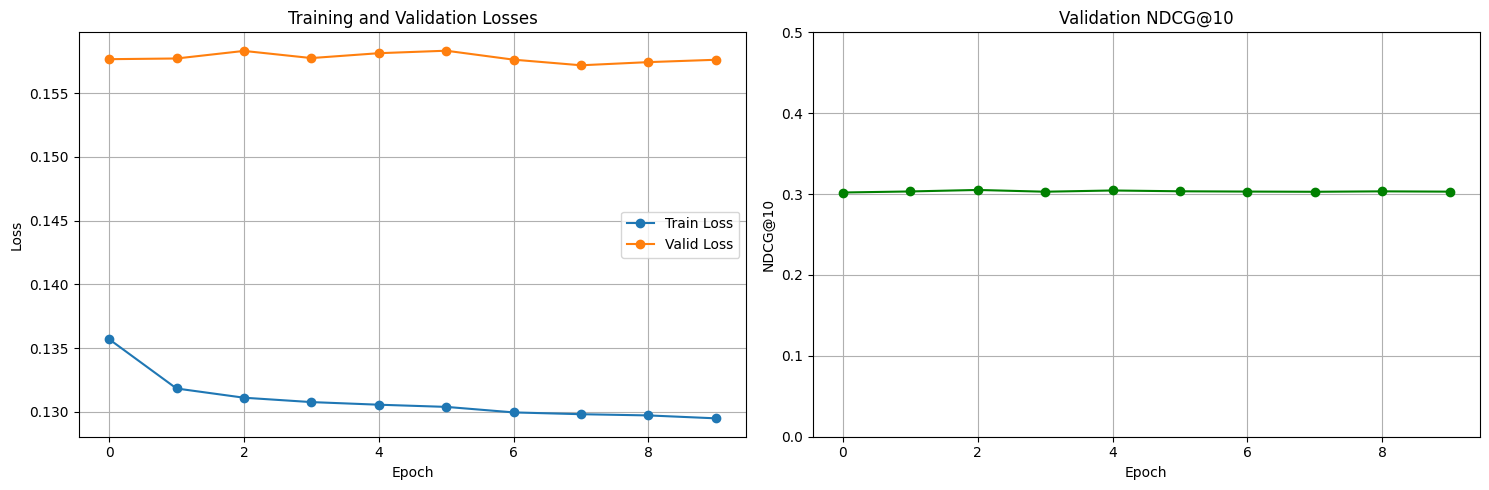

In [138]:
plot_metrics(train_losses, valid_losses, valid_ndcgs)

In [140]:
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'best_model.pth')))
model.eval()

test_preds = []
test_labels = []
user_test_preds = defaultdict(list)
user_test_labels = defaultdict(list)

with torch.no_grad():
    for h_vector, item_ids, labels, user_ids in test_loader:
        h_vector = h_vector.to(DEVICE)
        item_ids = item_ids.to(DEVICE)
        labels = labels.to(DEVICE)
        user_ids = user_ids.cpu().numpy()
        
        outputs = model(h_vector, item_ids)
        probs = torch.sigmoid(outputs).cpu().numpy()
        labels_cpu = labels.cpu().numpy()
        
        test_preds.extend(probs)
        test_labels.extend(labels_cpu)
        
        for i, user_id in enumerate(user_ids):
            user_test_preds[user_id].append(probs[i])
            user_test_labels[user_id].append(labels_cpu[i])

test_accuracy = calculate_accuracy(test_preds, test_labels)
test_ndcg_10 = calculate_ndcg(user_test_preds, user_test_labels, top_k=10)
test_recall_10 = calculate_recall(user_test_preds, user_test_labels, top_k=10)
test_ndcg_3 = calculate_ndcg(user_test_preds, user_test_labels, top_k=3)
test_recall_3 = calculate_recall(user_test_preds, user_test_labels, top_k=3)

print("\nFinal Test Results:")
print(f"  Accuracy:   {test_accuracy:.4f}")
print(f"  NDCG@10:       {test_ndcg_10:.4f}")
print(f"  Recall@10:       {test_recall_10:.4f}")
print(f"  NDCG@3:       {test_ndcg_3:.4f}")
print(f"  Recall@3:       {test_recall_3:.4f}")


Final Test Results:
  Accuracy:   0.9586
  NDCG@10:       0.2920
  Recall@10:       0.3427
  NDCG@3:       0.2633
  Recall@3:       0.1826


In [ ]:
# попробую T=100

In [149]:
T = 5
EPOCHS = 10

train_df = pd.read_csv('train_baskets.csv')
valid_df = pd.read_csv('valid_baskets.csv')
test_df = pd.read_csv('test_baskets.csv')

processor = BasketSequenceProcessor(T)
train_sequences = processor.build_user_sequences(train_df)
train_data = processor.create_dataset(train_sequences, 'train')
full_valid_df = pd.concat([train_df, valid_df])
valid_sequences = processor.build_user_sequences(full_valid_df)
valid_data = processor.create_dataset(valid_sequences, 'valid')
full_test_df = pd.concat([train_df, valid_df, test_df])
test_sequences = processor.build_user_sequences(full_test_df)
test_data = processor.create_dataset(test_sequences, 'test')

train_dataset = BasketDataset(train_data)
valid_dataset = BasketDataset(valid_data)
test_dataset = BasketDataset(test_data)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Preparing dataset: 100%|██████████| 2500/2500 [00:00<00:00, 16224.62it/s]


In [150]:
num_items = max(
    train_df['item_id_decoded'].max(),
    valid_df['item_id_decoded'].max(),
    test_df['item_id_decoded'].max()
) + 1

model = BasketHSERec(
    num_items, T, EMBEDDING_DIM, HIDDEN_DIMS).to(DEVICE)

print("\nStarting training...")
train_losses, valid_losses, valid_ndcgs = train_model(
    model, train_loader, valid_loader
)


Starting training...


Epoch 1/10 [Train]: 100%|██████████| 5232/5232 [03:26<00:00, 25.34it/s, loss=0.209]



Epoch 1/10:
  Train Loss: 0.1673
  Valid Loss: 0.1835
  Valid Accuracy: 0.9489
  Valid NDCG@10: 0.3054
  Valid Recall@10: 0.3826
  Saved best model!


Epoch 2/10 [Train]: 100%|██████████| 5232/5232 [03:24<00:00, 25.60it/s, loss=0.142]



Epoch 2/10:
  Train Loss: 0.1607
  Valid Loss: 0.1841
  Valid Accuracy: 0.9489
  Valid NDCG@10: 0.3058
  Valid Recall@10: 0.3816
  Saved best model!


...


Epoch 8/10:
  Train Loss: 0.1573
  Valid Loss: 0.1851
  Valid Accuracy: 0.9490
  Valid NDCG@10: 0.3063
  Valid Recall@10: 0.3843


Epoch 9/10 [Train]: 100%|██████████| 5232/5232 [03:23<00:00, 25.66it/s, loss=0.216]



Epoch 9/10:
  Train Loss: 0.1572
  Valid Loss: 0.1836
  Valid Accuracy: 0.9490
  Valid NDCG@10: 0.3060
  Valid Recall@10: 0.3846


Epoch 10/10 [Train]: 100%|██████████| 5232/5232 [03:25<00:00, 25.51it/s, loss=0.196]



Epoch 10/10:
  Train Loss: 0.1571
  Valid Loss: 0.1842
  Valid Accuracy: 0.9489
  Valid NDCG@10: 0.3049
  Valid Recall@10: 0.3826


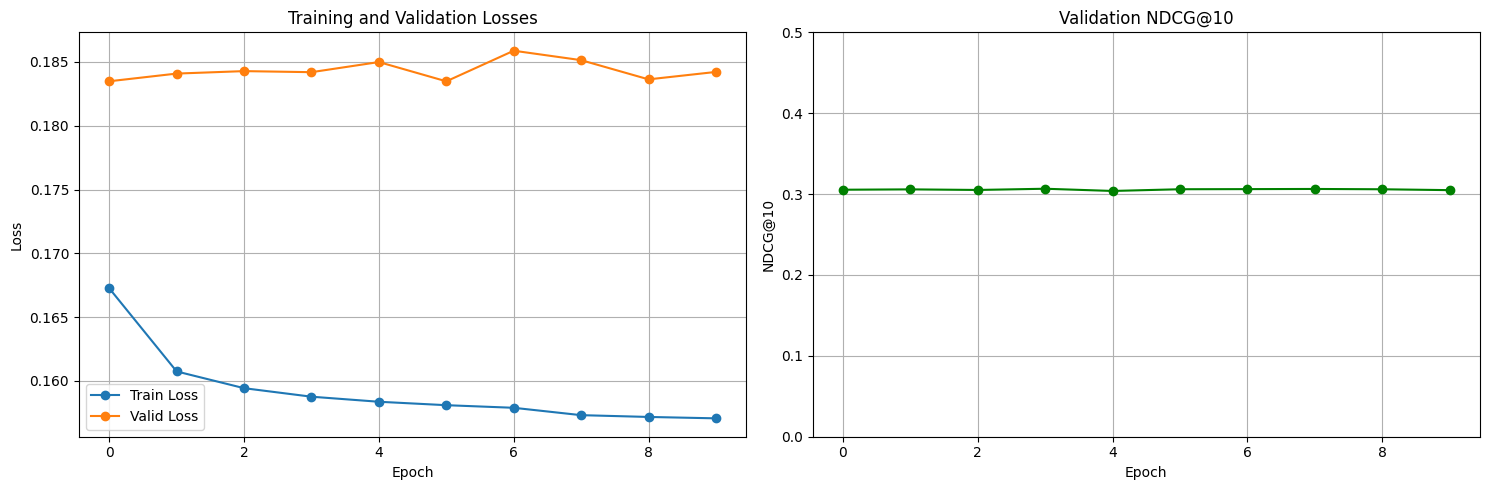

In [151]:
plot_metrics(train_losses, valid_losses, valid_ndcgs)

In [152]:
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'best_model.pth')))
model.eval()

test_preds = []
test_labels = []
user_test_preds = defaultdict(list)
user_test_labels = defaultdict(list)

with torch.no_grad():
    for h_vector, item_ids, labels, user_ids in test_loader:
        h_vector = h_vector.to(DEVICE)
        item_ids = item_ids.to(DEVICE)
        labels = labels.to(DEVICE)
        user_ids = user_ids.cpu().numpy()
        
        outputs = model(h_vector, item_ids)
        probs = torch.sigmoid(outputs).cpu().numpy()
        labels_cpu = labels.cpu().numpy()
        
        test_preds.extend(probs)
        test_labels.extend(labels_cpu)
        
        for i, user_id in enumerate(user_ids):
            user_test_preds[user_id].append(probs[i])
            user_test_labels[user_id].append(labels_cpu[i])

test_accuracy = calculate_accuracy(test_preds, test_labels)
test_ndcg_10 = calculate_ndcg(user_test_preds, user_test_labels, top_k=10)
test_recall_10 = calculate_recall(user_test_preds, user_test_labels, top_k=10)
test_ndcg_3 = calculate_ndcg(user_test_preds, user_test_labels, top_k=3)
test_recall_3 = calculate_recall(user_test_preds, user_test_labels, top_k=3)

print("\nFinal Test Results:")
print(f"  Accuracy:   {test_accuracy:.4f}")
print(f"  NDCG@10:       {test_ndcg_10:.4f}")
print(f"  Recall@10:       {test_recall_10:.4f}")
print(f"  NDCG@3:       {test_ndcg_3:.4f}")
print(f"  Recall@3:       {test_recall_3:.4f}")


Final Test Results:
  Accuracy:   0.9488
  NDCG@10:       0.2994
  Recall@10:       0.3715
  NDCG@3:       0.2610
  Recall@3:       0.2055


In [156]:
T = 20
EPOCHS = 5

train_df = pd.read_csv('train_baskets.csv')
valid_df = pd.read_csv('valid_baskets.csv')
test_df = pd.read_csv('test_baskets.csv')

processor = BasketSequenceProcessor(T)
train_sequences = processor.build_user_sequences(train_df)
train_data = processor.create_dataset(train_sequences, 'train')
full_valid_df = pd.concat([train_df, valid_df])
valid_sequences = processor.build_user_sequences(full_valid_df)
valid_data = processor.create_dataset(valid_sequences, 'valid')
full_test_df = pd.concat([train_df, valid_df, test_df])
test_sequences = processor.build_user_sequences(full_test_df)
test_data = processor.create_dataset(test_sequences, 'test')

train_dataset = BasketDataset(train_data)
valid_dataset = BasketDataset(valid_data)
test_dataset = BasketDataset(test_data)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Preparing dataset: 100%|██████████| 2500/2500 [00:00<00:00, 2818.69it/s]


In [157]:
num_items = max(
    train_df['item_id_decoded'].max(),
    valid_df['item_id_decoded'].max(),
    test_df['item_id_decoded'].max()
) + 1

model = BasketHSERec(
    num_items, T, EMBEDDING_DIM, HIDDEN_DIMS).to(DEVICE)

print("\nStarting training...")
train_losses, valid_losses, valid_ndcgs = train_model(
    model, train_loader, valid_loader
)


Starting training...


Epoch 1/5 [Train]: 100%|██████████| 14358/14358 [08:56<00:00, 26.78it/s, loss=0.1]   



Epoch 1/5:
  Train Loss: 0.1043
  Valid Loss: 0.1296
  Valid Accuracy: 0.9674
  Valid NDCG@10: 0.2960
  Valid Recall@10: 0.3250
  Saved best model!


Epoch 2/5 [Train]: 100%|██████████| 14358/14358 [08:59<00:00, 26.61it/s, loss=0.102] 



Epoch 2/5:
  Train Loss: 0.1017
  Valid Loss: 0.1295
  Valid Accuracy: 0.9674
  Valid NDCG@10: 0.2946
  Valid Recall@10: 0.3219


...


Epoch 3/5:
  Train Loss: 0.1013
  Valid Loss: 0.1285
  Valid Accuracy: 0.9674
  Valid NDCG@10: 0.2940
  Valid Recall@10: 0.3237


Epoch 4/5 [Train]: 100%|██████████| 14358/14358 [08:48<00:00, 27.15it/s, loss=0.109] 



Epoch 4/5:
  Train Loss: 0.1011
  Valid Loss: 0.1286
  Valid Accuracy: 0.9675
  Valid NDCG@10: 0.2924
  Valid Recall@10: 0.3228


Epoch 5/5 [Train]: 100%|██████████| 14358/14358 [08:46<00:00, 27.30it/s, loss=0.0923]



Epoch 5/5:
  Train Loss: 0.1008
  Valid Loss: 0.1299
  Valid Accuracy: 0.9674
  Valid NDCG@10: 0.2918
  Valid Recall@10: 0.3209


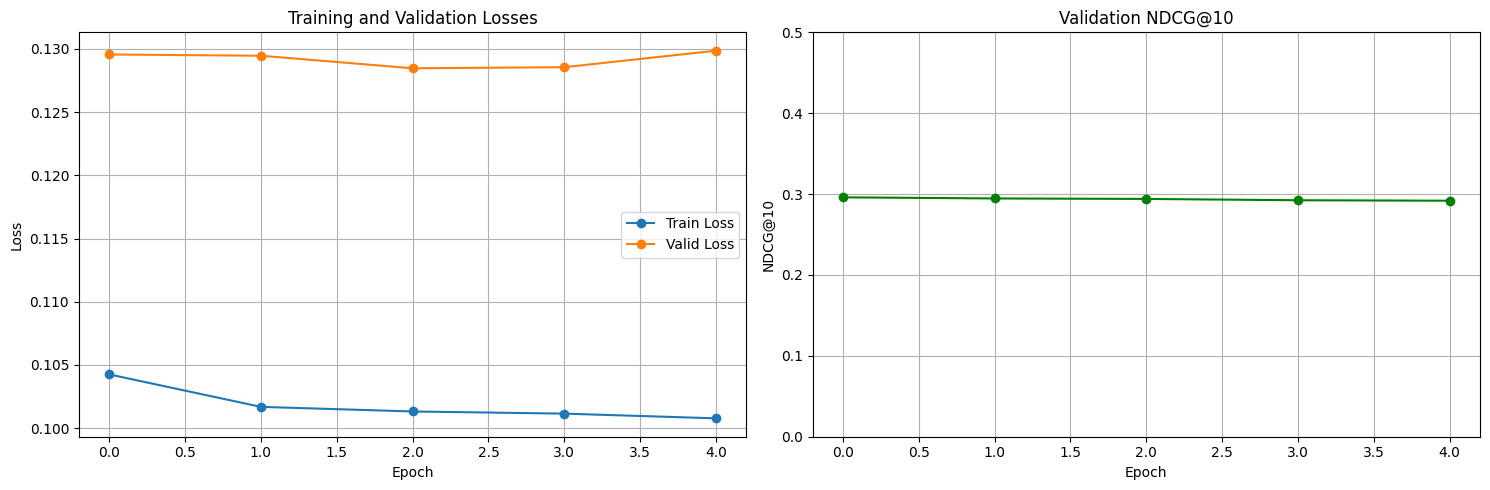

In [158]:
plot_metrics(train_losses, valid_losses, valid_ndcgs)

In [159]:
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'best_model.pth')))
model.eval()

test_preds = []
test_labels = []
user_test_preds = defaultdict(list)
user_test_labels = defaultdict(list)

with torch.no_grad():
    for h_vector, item_ids, labels, user_ids in test_loader:
        h_vector = h_vector.to(DEVICE)
        item_ids = item_ids.to(DEVICE)
        labels = labels.to(DEVICE)
        user_ids = user_ids.cpu().numpy()
        
        outputs = model(h_vector, item_ids)
        probs = torch.sigmoid(outputs).cpu().numpy()
        labels_cpu = labels.cpu().numpy()
        
        test_preds.extend(probs)
        test_labels.extend(labels_cpu)
        
        for i, user_id in enumerate(user_ids):
            user_test_preds[user_id].append(probs[i])
            user_test_labels[user_id].append(labels_cpu[i])

test_accuracy = calculate_accuracy(test_preds, test_labels)
test_ndcg_10 = calculate_ndcg(user_test_preds, user_test_labels, top_k=10)
test_recall_10 = calculate_recall(user_test_preds, user_test_labels, top_k=10)
test_ndcg_3 = calculate_ndcg(user_test_preds, user_test_labels, top_k=3)
test_recall_3 = calculate_recall(user_test_preds, user_test_labels, top_k=3)

print("\nFinal Test Results:")
print(f"  Accuracy:   {test_accuracy:.4f}")
print(f"  NDCG@10:       {test_ndcg_10:.4f}")
print(f"  Recall@10:       {test_recall_10:.4f}")
print(f"  NDCG@3:       {test_ndcg_3:.4f}")
print(f"  Recall@3:       {test_recall_3:.4f}")


Final Test Results:
  Accuracy:   0.9671
  NDCG@10:       0.2865
  Recall@10:       0.3118
  NDCG@3:       0.2705
  Recall@3:       0.1610


`Стоило бы попробовать другие архитектуры модели: добавить больше линейных слоев, увеличить/уменьшить их размеры, learning rate, но дедлайн нерезиновый :)`

### 4. Сравнение с TopPersonal (3 балла)


Представим сравнение двух подходов в табличном виде:

  | Модель               | NDCG@3 | Recall@3 | NDCG@10 | Recall@10 | Время обучения |
  |----------------------|--------|----------|---------|-----------|----------------|
  | TopPersonal          | 0.185  | 0.075    | 0.304   | 0.135     |  5 секунд      |
  | BaskerHSERec (T=5)   | 0.261  | 0.206    | 0.299   | 0.372     |  3 мин/эпоха   |
  | BaskerHSERec (T=10)  | 0.263  | 0.183    | 0.292   | 0.343     |  5 мин/эпоха   |
  | BaskerHSERec (T=20)  | 0.2705 | 0.161    | 0.287   | 0.312          |  9 мин/эпоха   |

**Выводы:**

1. Видим, что каждая из BasketHSERec моделей оказалась лучше бейзлайна по метрикам (по некоторым даже более чем в 2 раза!)
2. Каждая из моделей BasketHSERec довольно быстро начинает переобучаться (уже после 2-3 эпохи): лосс на трейне продолжает падать, а на валидации - нет. Стоит пересмотреть архитектуру модели, ее слои.
3. При увеличении горизонта (T: 5 -> 10 -> 20) модель начинает переобучаться и метрики падают (за исключением NDCG@3).

### 5. Анализ архитектурных решений (2 балла)

In [169]:
T = 10
EPOCHS = 10
SAVE_DIR = "model_comparison"
os.makedirs(SAVE_DIR, exist_ok=True)

train_df = pd.read_csv('train_baskets.csv')
valid_df = pd.read_csv('valid_baskets.csv')
test_df = pd.read_csv('test_baskets.csv')

processor = BasketSequenceProcessor(T)
train_sequences = processor.build_user_sequences(train_df)
train_data = processor.create_dataset(train_sequences, 'train')
full_valid_df = pd.concat([train_df, valid_df])
valid_sequences = processor.build_user_sequences(full_valid_df)
valid_data = processor.create_dataset(valid_sequences, 'valid')
full_test_df = pd.concat([train_df, valid_df, test_df])
test_sequences = processor.build_user_sequences(full_test_df)
test_data = processor.create_dataset(test_sequences, 'test')

train_dataset = BasketDataset(train_data)
valid_dataset = BasketDataset(valid_data)
test_dataset = BasketDataset(test_data)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Preparing dataset: 100%|██████████| 2500/2500 [00:00<00:00, 7416.76it/s]


In [170]:
class BasketHSERec_modified(nn.Module):
    def __init__(self, num_items, T, embedding_dim, hidden_dims, use_history=True, use_embeddings=True):
        super().__init__()
        self.use_history = use_history
        self.use_embeddings = use_embeddings
        self.T = T
    
        if use_embeddings:
            self.item_embedding = nn.Embedding(num_items, embedding_dim)
        
        input_dim = 0
        if use_history:
            input_dim += T
        if use_embeddings:
            input_dim += embedding_dim
        
        layers = []
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2))
            input_dim = hidden_dim
        layers.append(nn.Linear(input_dim, 1))
        
        self.mlp = nn.Sequential(*layers)
        
    def forward(self, h_vector, item_ids):
        inputs = []
        if self.use_history:
            inputs.append(h_vector)
        if self.use_embeddings:
            item_emb = self.item_embedding(item_ids)
            inputs.append(item_emb)
        x = torch.cat(inputs, dim=1) if len(inputs) > 1 else inputs[0]
        return self.mlp(x).squeeze()

In [175]:
model = BasketHSERec_modified(num_items, T, EMBEDDING_DIM, HIDDEN_DIMS, use_embeddings=True, use_history=False).to(DEVICE)
print("\nStarting training...")
train_losses, valid_losses, valid_ndcgs = train_model(
    model, train_loader, valid_loader
)


Starting training...


Epoch 1/10 [Train]: 100%|██████████| 9047/9047 [05:25<00:00, 27.75it/s, loss=0.0742]



Epoch 1/10:
  Train Loss: 0.1443
  Valid Loss: 0.1666
  Valid Accuracy: 0.9582
  Valid NDCG@10: 0.2498
  Valid Recall@10: 0.3114
  Saved best model!


Epoch 2/10 [Train]: 100%|██████████| 9047/9047 [05:28<00:00, 27.52it/s, loss=0.142] 



Epoch 2/10:
  Train Loss: 0.1392
  Valid Loss: 0.1664
  Valid Accuracy: 0.9582
  Valid NDCG@10: 0.2491
  Valid Recall@10: 0.3147


...


Epoch 8/10:
  Train Loss: 0.1374
  Valid Loss: 0.1667
  Valid Accuracy: 0.9582
  Valid NDCG@10: 0.2432
  Valid Recall@10: 0.3083


Epoch 9/10 [Train]: 100%|██████████| 9047/9047 [05:30<00:00, 27.39it/s, loss=0.134] 



Epoch 9/10:
  Train Loss: 0.1373
  Valid Loss: 0.1663
  Valid Accuracy: 0.9582
  Valid NDCG@10: 0.2494
  Valid Recall@10: 0.3098


Epoch 10/10 [Train]: 100%|██████████| 9047/9047 [05:29<00:00, 27.49it/s, loss=0.152] 



Epoch 10/10:
  Train Loss: 0.1372
  Valid Loss: 0.1664
  Valid Accuracy: 0.9582
  Valid NDCG@10: 0.2448
  Valid Recall@10: 0.3100


In [176]:
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'best_model.pth')))
model.eval()

test_preds = []
test_labels = []
user_test_preds = defaultdict(list)
user_test_labels = defaultdict(list)

with torch.no_grad():
    for h_vector, item_ids, labels, user_ids in test_loader:
        h_vector = h_vector.to(DEVICE)
        item_ids = item_ids.to(DEVICE)
        labels = labels.to(DEVICE)
        user_ids = user_ids.cpu().numpy()
        
        outputs = model(h_vector, item_ids)
        probs = torch.sigmoid(outputs).cpu().numpy()
        labels_cpu = labels.cpu().numpy()
        
        test_preds.extend(probs)
        test_labels.extend(labels_cpu)
        
        for i, user_id in enumerate(user_ids):
            user_test_preds[user_id].append(probs[i])
            user_test_labels[user_id].append(labels_cpu[i])

test_accuracy = calculate_accuracy(test_preds, test_labels)
test_ndcg_10 = calculate_ndcg(user_test_preds, user_test_labels, top_k=10)
test_recall_10 = calculate_recall(user_test_preds, user_test_labels, top_k=10)
test_ndcg_3 = calculate_ndcg(user_test_preds, user_test_labels, top_k=3)
test_recall_3 = calculate_recall(user_test_preds, user_test_labels, top_k=3)

print("\nFinal Test Results:")
print(f"  Accuracy:   {test_accuracy:.4f}")
print(f"  NDCG@10:       {test_ndcg_10:.4f}")
print(f"  Recall@10:       {test_recall_10:.4f}")
print(f"  NDCG@3:       {test_ndcg_3:.4f}")
print(f"  Recall@3:       {test_recall_3:.4f}")


Final Test Results:
  Accuracy:   0.9586
  NDCG@10:       0.2412
  Recall@10:       0.2946
  NDCG@3:       0.2139
  Recall@3:       0.1531


In [177]:
model = BasketHSERec_modified(
    num_items, T, EMBEDDING_DIM, HIDDEN_DIMS, use_embeddings=False, use_history=True).to(DEVICE)

print("\nStarting training...")
train_losses, valid_losses, valid_ndcgs = train_model(
    model, train_loader, valid_loader
)


Starting training...


Epoch 1/10 [Train]: 100%|██████████| 9047/9047 [04:30<00:00, 33.49it/s, loss=0.112] 



Epoch 1/10:
  Train Loss: 0.1396
  Valid Loss: 0.1600
  Valid Accuracy: 0.9583
  Valid NDCG@10: 0.2677
  Valid Recall@10: 0.2998
  Saved best model!


Epoch 2/10 [Train]: 100%|██████████| 9047/9047 [04:26<00:00, 33.90it/s, loss=0.121] 



Epoch 2/10:
  Train Loss: 0.1368
  Valid Loss: 0.1598
  Valid Accuracy: 0.9584
  Valid NDCG@10: 0.2664
  Valid Recall@10: 0.2991


...


Epoch 8/10:
  Train Loss: 0.1364
  Valid Loss: 0.1601
  Valid Accuracy: 0.9582
  Valid NDCG@10: 0.2718
  Valid Recall@10: 0.3085


Epoch 9/10 [Train]: 100%|██████████| 9047/9047 [04:39<00:00, 32.32it/s, loss=0.193] 



Epoch 9/10:
  Train Loss: 0.1364
  Valid Loss: 0.1595
  Valid Accuracy: 0.9583
  Valid NDCG@10: 0.2734
  Valid Recall@10: 0.3089
  Saved best model!


Epoch 10/10 [Train]: 100%|██████████| 9047/9047 [04:41<00:00, 32.19it/s, loss=0.16]  



Epoch 10/10:
  Train Loss: 0.1364
  Valid Loss: 0.1597
  Valid Accuracy: 0.9583
  Valid NDCG@10: 0.2691
  Valid Recall@10: 0.3014


In [178]:
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'best_model.pth')))
model.eval()

test_preds = []
test_labels = []
user_test_preds = defaultdict(list)
user_test_labels = defaultdict(list)

with torch.no_grad():
    for h_vector, item_ids, labels, user_ids in test_loader:
        h_vector = h_vector.to(DEVICE)
        item_ids = item_ids.to(DEVICE)
        labels = labels.to(DEVICE)
        user_ids = user_ids.cpu().numpy()
        
        outputs = model(h_vector, item_ids)
        probs = torch.sigmoid(outputs).cpu().numpy()
        labels_cpu = labels.cpu().numpy()
        
        test_preds.extend(probs)
        test_labels.extend(labels_cpu)
        
        for i, user_id in enumerate(user_ids):
            user_test_preds[user_id].append(probs[i])
            user_test_labels[user_id].append(labels_cpu[i])

test_accuracy = calculate_accuracy(test_preds, test_labels)
test_ndcg_10 = calculate_ndcg(user_test_preds, user_test_labels, top_k=10)
test_recall_10 = calculate_recall(user_test_preds, user_test_labels, top_k=10)
test_ndcg_3 = calculate_ndcg(user_test_preds, user_test_labels, top_k=3)
test_recall_3 = calculate_recall(user_test_preds, user_test_labels, top_k=3)

print("\nFinal Test Results:")
print(f"  Accuracy:   {test_accuracy:.4f}")
print(f"  NDCG@10:       {test_ndcg_10:.4f}")
print(f"  Recall@10:       {test_recall_10:.4f}")
print(f"  NDCG@3:       {test_ndcg_3:.4f}")
print(f"  Recall@3:       {test_recall_3:.4f}")


Final Test Results:
  Accuracy:   0.9586
  NDCG@10:       0.2596
  Recall@10:       0.2966
  NDCG@3:       0.2414
  Recall@3:       0.1612


  **Итоговая таблица:**
  
  | Вариант                 | NDCG@3 | Recall@3 | NDCG@10 | Recall@10 |
  |-------------------------|--------|----------|---------|-----------|
  | a) History + Embeddings | 0.263  | 0.183    | 0.292   | 0.343     |
  | b) Только Embeddings    | 0.214  | 0.153    | 0.241   | 0.295     |
  | c) Только History       | 0.241  | 0.161    | 0.260   | 0.297     |
  | TopPersonal (baseline)  | 0.185  | 0.075    | 0.304   | 0.135     |


  **Выводы**:

1. Модель BasketHSERec оказалась лучше бейзлайна по метрикам.
2. Наиболее важной компонентой в модели BasketHSERec является история взаимодействия юзера с айтемом за последние T дней.
3. Можно подобрать наилучшие гиперпараметры и получить лучшие метрики у модели BasketHSERec, но это потребует доп ресурсов.
4. Также в данной задаче стоило бы попробовать другие модели: TIFU-KNN, UP-CF. 